# Sanity Check (YOLO Model)

This notebook contains a quick sanity check to ensure the model is able to train as expected using the implementation. It is using a very small subset of the dataset to run and identify issues quickly.

In [1]:
import sys

import matplotlib.pyplot as plt

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import detect
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(detect)
importlib.reload(dataset);

We start by training the YOLO model with the custom keypoints head on a very small subset of the complete dataset. 

In [4]:
model = detect.CustomHeadedYolo(path="../nets")

# Train the model for some epochs in the dummy dataset.
detect.train_epochs_in(100, None, None, model, testing=True)

epoch 0; train: loss 32.92738342285156; val: loss 24.48073387145996
epoch 1; train: loss 21.917094548543293; val: loss 19.711570739746094
epoch 2; train: loss 19.58991241455078; val: loss 22.134159088134766
epoch 3; train: loss 18.417612711588543; val: loss 21.635839462280273
epoch 4; train: loss 18.205336888631184; val: loss 20.425853729248047
epoch 5; train: loss 18.041728337605793; val: loss 19.685720443725586
epoch 6; train: loss 17.899662653605144; val: loss 19.242748260498047
epoch 7; train: loss 17.744225184122723; val: loss 18.65255355834961
epoch 8; train: loss 17.594523747762043; val: loss 18.228002548217773
epoch 9; train: loss 17.44286282857259; val: loss 18.029342651367188
epoch 10; train: loss 17.30118751525879; val: loss 17.95928192138672
epoch 11; train: loss 17.15778986612956; val: loss 17.783252716064453
epoch 12; train: loss 16.978941599527996; val: loss 17.653114318847656
epoch 13; train: loss 16.784539540608723; val: loss 17.566341400146484
epoch 14; train: loss 16

As can be seen above, the basic implementation of the training loop works, decreasing the loss significantly over the epochs. Obviously this is just on a very small subset of the data so we expect significant overfitting to take place here. Below we look at some examples of applying the learned detector on some example images.

In [ ]:
# Load one example sample from the dataset.
data = dataset.YoloDataset("../data/yolo/train")
img, ann = data[32]
# Try to run the learned detector on the sample.
detector = detect.CustomPoseDetector(model)
mean, cov = detector.detect_simple(img.unsqueeze(0).to("cuda"))[0]
# Try also to use the baseline YOLO model.
detector2 = detect.PoseDetector(path="../nets", compile=False)
mean2, cov2 = detector2.detect_simple(img.unsqueeze(0))[0]

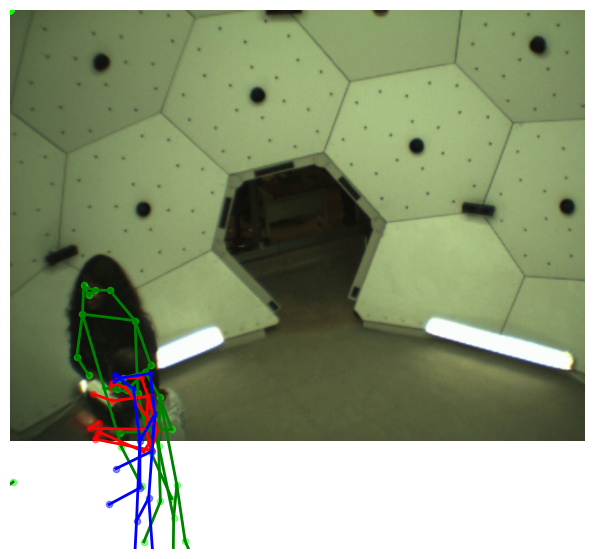

In [10]:
# Visualize the results.
plt.figure(figsize=(8, 7))
for kp in ann:
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='green', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#00ff0070')
for kp in mean2.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#ff000070')
for kp in mean.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='blue', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
plt.imshow(img.permute(1, 2, 0))
plt.ylim(600, 0)
plt.axis("off")
plt.show()

As can be seen above, the predictions are not perfect, but they are also not terrible. Note that the red one is the native YOLO prediction, the blue one is the custom heads predictions, and the green skeletons are the ground truth.